# 04 — Random Forest

**O que é:** ensemble de múltiplas árvores de decisão, onde cada árvore é treinada em uma amostra aleatória dos dados (bootstrap) e usa subconjunto aleatório de features. A previsão final é a votação majoritária das árvores.

**Vantagens:** robusto a outliers, captura não-linearidades, fornece importância das features.

**Desvantagens:** menos interpretável que regressão logística, mais lento.

## Carregamento e Preparação (igual ao notebook 03)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import joblib
from IPython.display import Image, display
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 1 if str(x).strip().lower() == 'rebaixado' else 0)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES])
y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES])
y_te = df_te[TARGET].values

print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 3) | Teste: (40, 3)


## Treinamento do Random Forest

Usamos `class_weight='balanced'` e `n_estimators=100` árvores.

In [2]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_tr, y_tr)

print('Modelo treinado com sucesso!')
print(f'Classes: {rf.classes_}  (0=Permaneceu, 1=Rebaixado)')
print(f'Numero de arvores: {rf.n_estimators}')
print(f'Class weight     : {rf.class_weight}')

Modelo treinado com sucesso!
Classes: [0 1]  (0=Permaneceu, 1=Rebaixado)
Numero de arvores: 300
Class weight     : balanced


## Avaliação no Conjunto de Teste

Acuracia no teste: 0.7750 (77.50%)

Relatorio de Classificacao:
              precision    recall  f1-score   support

  Permaneceu       0.79      0.97      0.87        32
   Rebaixado       0.00      0.00      0.00         8

    accuracy                           0.78        40
   macro avg       0.40      0.48      0.44        40
weighted avg       0.64      0.78      0.70        40



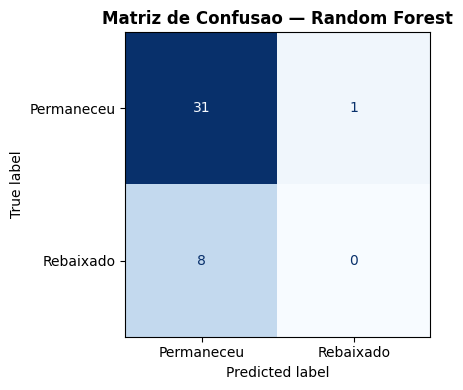

In [3]:
y_pred = rf.predict(X_te)
acc = accuracy_score(y_te, y_pred)
print(f'Acuracia no teste: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Relatorio de Classificacao:')
print(classification_report(y_te, y_pred, target_names=['Permaneceu', 'Rebaixado']))

os.makedirs(os.path.join('..', 'img'), exist_ok=True)
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Permaneceu', 'Rebaixado'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusao — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'cm_random_forest.png'), dpi=150)
plt.show()

## Curva ROC e AUC

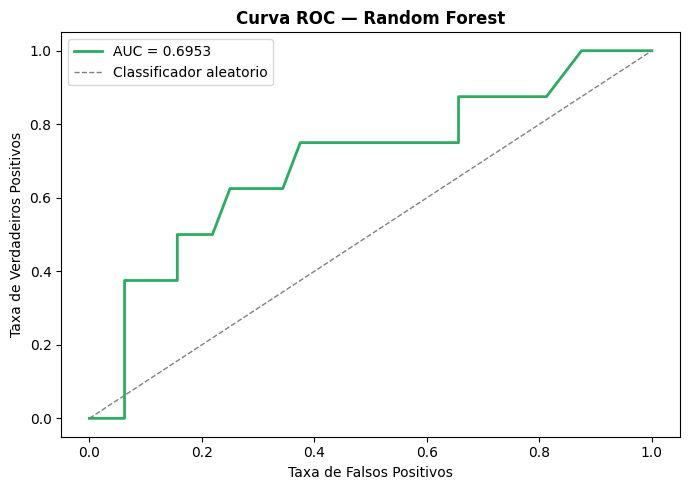

AUC: 0.6953


In [4]:
y_prob = rf.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#27ae60', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador aleatorio')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Random Forest', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'roc_random_forest.png'), dpi=150)
plt.show()
print(f'AUC: {roc_auc:.4f}')

## Importância das Features

               Feature  Importancia
Valor de Mercado Total       0.4924
               Plantel       0.3397
          Estrangeiros       0.1679


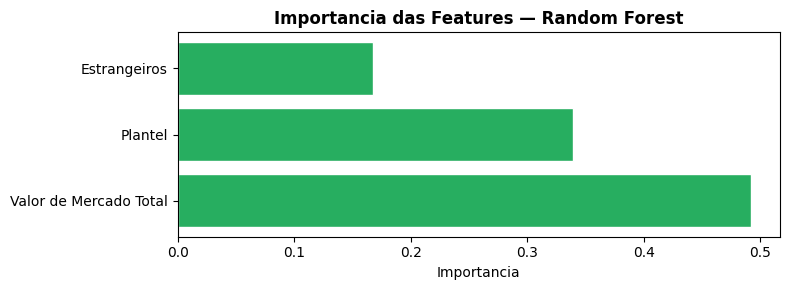

In [5]:
importancias = pd.DataFrame({
    'Feature': FEATURES,
    'Importancia': rf.feature_importances_.round(4)
}).sort_values('Importancia', ascending=False)

print(importancias.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(importancias['Feature'], importancias['Importancia'], color='#27ae60', edgecolor='white')
ax.set_xlabel('Importancia')
ax.set_title('Importancia das Features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'feat_importance_rf.png'), dpi=150)
plt.show()

## Probabilidades por Clube no Conjunto de Teste

In [6]:
probs = rf.predict_proba(X_te)
idx_reb = list(rf.classes_).index(1)

df_res = df_te[['Clube', 'Temporada']].copy()
df_res['Prob_Rebaixamento(%)'] = (probs[:, idx_reb] * 100).round(2)
df_res['Real']     = y_te
df_res['Previsto'] = rf.predict(X_te)
df_res = df_res.sort_values('Prob_Rebaixamento(%)', ascending=False)

print('Probabilidades de rebaixamento (conjunto de teste):')
df_res

Probabilidades de rebaixamento (conjunto de teste):


,Clube,Temporada,Prob_Rebaixamento(%),Real,Previsto
219,Juventude,2024,50.33,0,1
217,Vitoria,2024,50.00,0,0
198,Goias,2023,45.00,1,0
215,Atletico Goianiense,2024,36.67,1,0
197,America Mineiro,2023,35.00,1,0
203,Botafogo,2024,15.67,0,0
199,Cuiaba,2023,14.00,0,0
182,Botafogo,2023,11.67,0,0
194,Coritiba,2023,9.00,1,0
205,Internacional,2024,8.33,0,0


## Salvando o Modelo

In [7]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
joblib.dump(rf,     os.path.join('..', 'modelos', 'random_forest.pkl'))
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_rf.pkl'))
print('Modelo salvo em modelos/random_forest.pkl')
print('Scaler salvo em modelos/scaler_rf.pkl')

Modelo salvo em modelos/random_forest.pkl
Scaler salvo em modelos/scaler_rf.pkl


## Comparação com Regressão Logística

Descreva brevemente as diferenças observadas nas métricas e na importância das features.

**Pontos a observar:**
- Compare a acurácia e o AUC entre Random Forest e Regressão Logística.
- Verifique se a ordem de importância das features (Gini) coincide com os coeficientes do modelo linear.
- O Random Forest tende a ter maior robustez a ruído e outliers, mas pode sofrer de overfitting em conjuntos pequenos.
- Com apenas 3 features e ~180 registros de treino, os dois modelos devem apresentar desempenhos próximos.